# Logistic Regression (LR)
Logistic regression is een statistische methode die wordt gebruikt voor binaire classificatieproblemen. Het model voorspelt de waarschijnlijkheid dat een gegeven invoer tot een bepaalde klasse behoort. In tegenstelling tot lineaire regressie, die continue uitkomsten voorspelt, gebruikt logistieke regressie een logistische functie om de uitkomst te beperken tot een waarde tussen 0 en 1. Dit komt niet helemaal overeen met ons doel, omdat wij een multiclass classificatie probleem hebben. Echter, we kunnen de "one-vs-rest" (OvR) benadering gebruiken, waarbij voor elke klasse een afzonderlijk binair classificatiemodel wordt getraind.

Naast Logistic Regression gaan we ook andere modellen proberen zoals Decision Tree, Random Forest, SVM, MLP, Naive Bayes en KNN om te zien welk model het beste presteert op onze dataset. De KPI's zullen worden gebruikt om de prestaties van elk model te vergelijken en te bepalen welk model het meest geschikt is voor onze toepassing. De andere modellen worden in andere bestanden uitgewerkt.

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from utils.baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report
from utils.normalization_functions import Normalizer
from utils.pca_analysis_functions import PCAAnalyzer, quick_pca_analysis
from utils.lda_analysis_functions import quick_lda_analysis
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
%%time
df = pd.read_csv("../data/csv/processed_data.csv")

CPU times: total: 1min 39s
Wall time: 1min 39s


In [3]:
%%time
Preprocessor = LibsDataPreprocessor()
X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(df)

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 8191)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 8191)
Test dataset shape: (10291, 8191)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 8188 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 8188)
Test features shape: (10291, 8188)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]
CPU times: total

Normalizing features...
Applying SNV normalization to dataset:
  - Samples: 41162
  - Verification (first spectrum): mean=0.000000, std=1.000000
  - SNV normalization completed successfully!
Applying SNV normalization to dataset:
  - Samples: 10291
  - Verification (first spectrum): mean=-0.000000, std=1.000000
  - SNV normalization completed successfully!
Data preprocessing completed successfully!


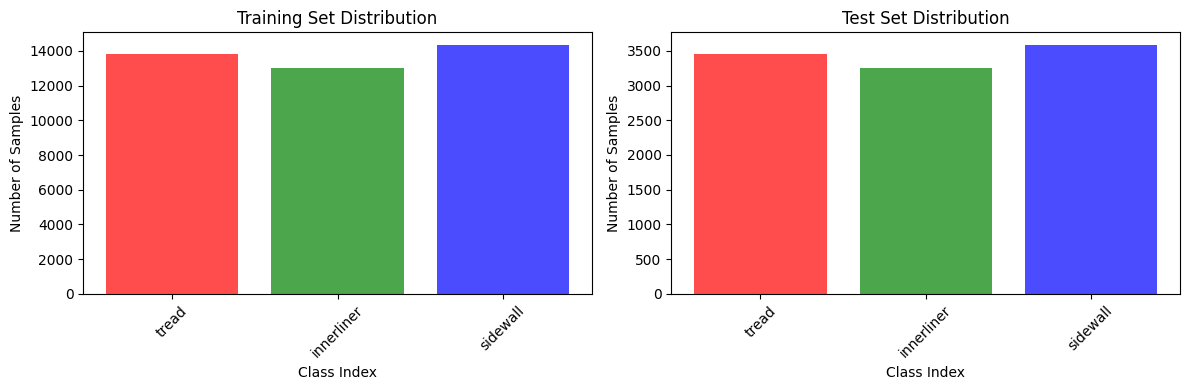

CPU times: total: 26.7 s
Wall time: 35.3 s


In [4]:
%%time
# Feature normalization 
print("Normalizing features...")
normaliser = Normalizer()
X_train_scaled = normaliser.apply_standard_normal_variate_on_dataset(X_train)
X_test_scaled = normaliser.apply_standard_normal_variate_on_dataset(X_test)
print("Data preprocessing completed successfully!")

# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train_encoded, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class Index')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

# Test set distribution
test_unique, test_counts = np.unique(y_test_encoded, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class Index')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

plt.tight_layout()
plt.show()

# Uitgebreide Logistieke Regressie Analyse
In deze sectie voeren we een uitgebreide Logistic Regression analyse uit. We testen verschillende configuraties en vergelijken de prestaties met en zonder dimensionaliteitsreductie. Logistic Regression gebruikt de "one-vs-rest" benadering voor multi-class classificatie.

## 1. Logistieke Regressie op originele features

In [ ]:


# 1. Logistic Regression on Original Features
print("=" * 60)
print("1. LOGISTIC REGRESSION ON ORIGINAL FEATURES")
print("=" * 60)

# Define parameter grid for Logistic Regression hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],  # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],  # Regularization type
    'solver': ['liblinear', 'saga'],  # Solvers that support all penalties
    'max_iter': [1000, 2000, 5000]  # Max iterations for convergence
}

print("Performing hyperparameter tuning with GridSearchCV...")
print("Note: This may take some time due to high dimensionality...")

# Grid search for optimal parameters
lr_original = LogisticRegression(random_state=42, multi_class='ovr')  # One-vs-Rest for multi-class
grid_search = GridSearchCV(
    lr_original, 
    param_grid, 
    cv=3,  # Reduced CV folds for faster computation with high dimensions
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=1
)

grid_search.fit(X_train_scaled, y_train_encoded)

# Get best parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

# Train final model with best parameters
lr_best = LogisticRegression(**best_params, random_state=42, multi_class='ovr')
lr_best.fit(X_train_scaled, y_train_encoded)

# Make predictions
y_pred_original = lr_best.predict(X_test_scaled)

# Calculate accuracy
accuracy_original = accuracy_score(y_test_encoded, y_pred_original)
print(f"\nLogistic Regression Accuracy on Original Features: {accuracy_original:.4f}")

# Classification report
print("\nClassification Report (Original Features):")
print(classification_report(y_test_encoded, y_pred_original, 
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_original = confusion_matrix(y_test_encoded, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression on Original Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance analysis using coefficient weights
feature_names = X_train.columns
n_classes = len(label_encoder.classes_)

if n_classes == 2:
    # Binary classification - single coefficient vector
    coefficients = lr_best.coef_[0]
    abs_coef = np.abs(coefficients)
else:
    # Multi-class - average absolute coefficients across all classes
    coefficients = lr_best.coef_
    abs_coef = np.mean(np.abs(coefficients), axis=0)

# Get top 20 most important features
top_indices = np.argsort(abs_coef)[-20:]
top_coefficients = abs_coef[top_indices]
top_features = [feature_names[i] for i in top_indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_coefficients)), top_coefficients)
plt.yticks(range(len(top_coefficients)), [f'λ{feat}' for feat in top_features])
plt.xlabel('Average Absolute Coefficient Weight')
plt.title('Top 20 Most Important Wavelengths - Logistic Regression')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nModel convergence: {'Converged' if lr_best.n_iter_[0] < lr_best.max_iter else 'Did not converge'}")
print(f"Number of iterations: {lr_best.n_iter_[0] if hasattr(lr_best, 'n_iter_') else 'N/A'}")
print(f"Regularization strength (C): {lr_best.C}")
print(f"Penalty type: {lr_best.penalty}")

# Store results for comparison
lr_results = {
    'model': lr_best,
    'accuracy': accuracy_original,
    'params': best_params,
    'predictions': y_pred_original
}

1. LOGISTIC REGRESSION ON ORIGINAL FEATURES
Performing hyperparameter tuning with GridSearchCV...
Note: This may take some time due to high dimensionality...
Fitting 3 folds for each of 126 candidates, totalling 378 fits


In [ ]:
from sklearn.metrics import classification_report
pca_analyzer = PCAAnalyzer()
# Quick comprehensive PCA analysis with KNN
result = quick_pca_analysis(
    X_train_scaled, X_test_scaled, y_train_encoded, y_test_encoded,
    classifier_name='LR', label_encoder=label_encoder, plot=True
)

print(f"\n🏆 Best LR-PCA Configuration:")
print(f"   Components: {best_result['n_components']}")
print(f"   Accuracy: {best_result['accuracy']:.4f}")
print(f"   Variance explained: {best_result['variance_explained']:.3f}")

# Classification report for best result
print(f"\nClassification Report (PCA - {best_result['n_components']} components):")
print(classification_report(y_test, best_result['y_pred'], 
                        target_names=label_encoder.classes_))

# Plot confusion matrix for best result
pca_analyzer.plot_confusion_matrix(
y_test, best_result['y_pred'], 'LR PCA Confusion Matrix',
best_result['n_components'], label_encoder
)

# Get recommendations
recommendations = pca_analyzer.get_component_recommendations(lr_results)
if recommendations:
    print(f"\n💡 Component Recommendations:")
    print(f"   Speed optimized: {recommendations['speed_optimized']} components")
    print(f"   Accuracy optimized: {recommendations['accuracy_optimized']} components")
    if recommendations['balanced']:
        print(f"   Balanced: {recommendations['balanced']} components")

🚀 Starting quick PCA analysis...
Step 1: Fitting PCA analysis...
Performing comprehensive PCA analysis...


✅ PCA analysis completed successfully
   Components for 95% variance: 3027
   Components for 99% variance: 4760
Step 2: Evaluating performance...

🔍 Starting PCA performance evaluation...
Evaluating LR performance with PCA...
Testing components: [100, 200, 3027, 4760]
  Testing with 100 components...
Optimizing LR hyperparameters...
Optimal C: 1.0 (CV Score: 0.8954)
    ✅ LR with 100 components: 0.8937 (0.581 variance explained)
  Testing with 200 components...
Optimizing LR hyperparameters...
Optimal C: 1.0 (CV Score: 0.9070)
    ✅ LR with 200 components: 0.9077 (0.607 variance explained)
  Testing with 3027 components...


3. LDA ANALYSIS AND LOGISTIC REGRESSION ON LDA FEATURES
Number of classes: 3
Maximum LDA components: 2
LDA reduced dimensions: 2
LDA Explained Variance Ratio per component:
  Component 1: 0.6306
  Component 2: 0.3694


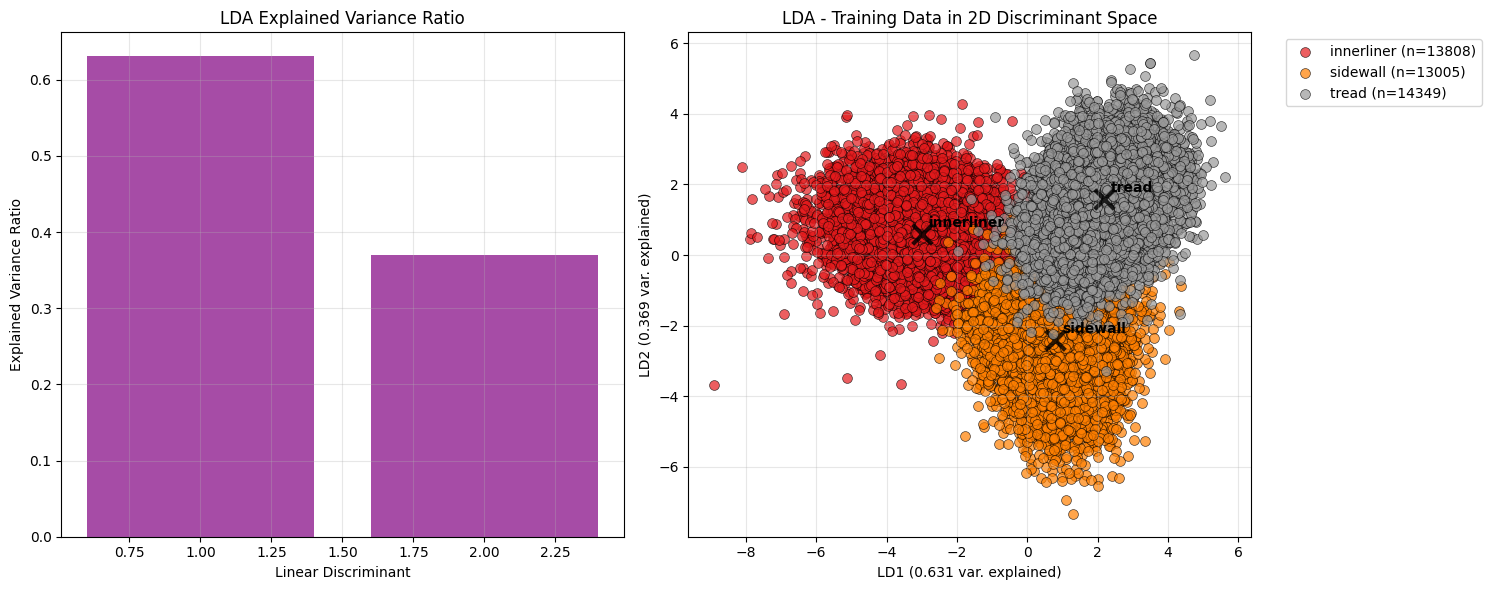


Training Logistic Regression on 2 LDA components...
Best LDA parameters: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Logistic Regression Accuracy on LDA Features: 0.9280

Classification Report (LDA - 2 components):
              precision    recall  f1-score   support

  innerliner       0.95      0.94      0.95      3452
    sidewall       0.90      0.92      0.91      3252
       tread       0.94      0.92      0.93      3587

    accuracy                           0.93     10291
   macro avg       0.93      0.93      0.93     10291
weighted avg       0.93      0.93      0.93     10291



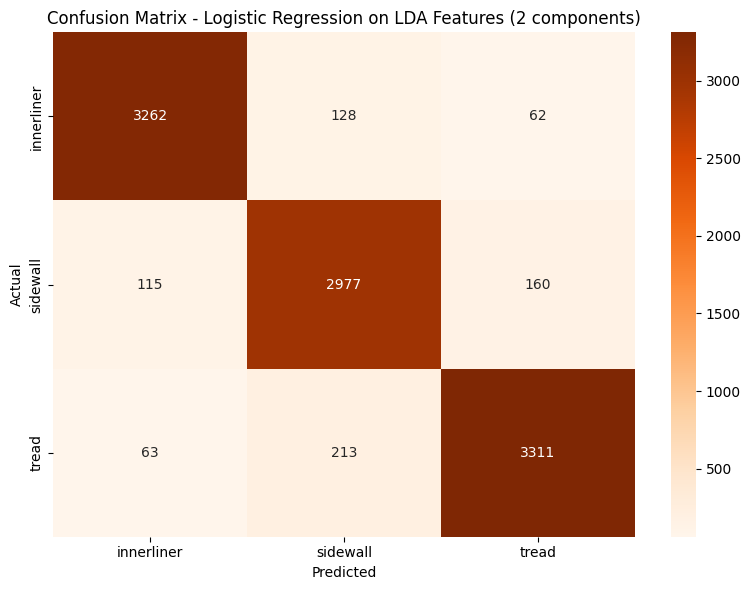

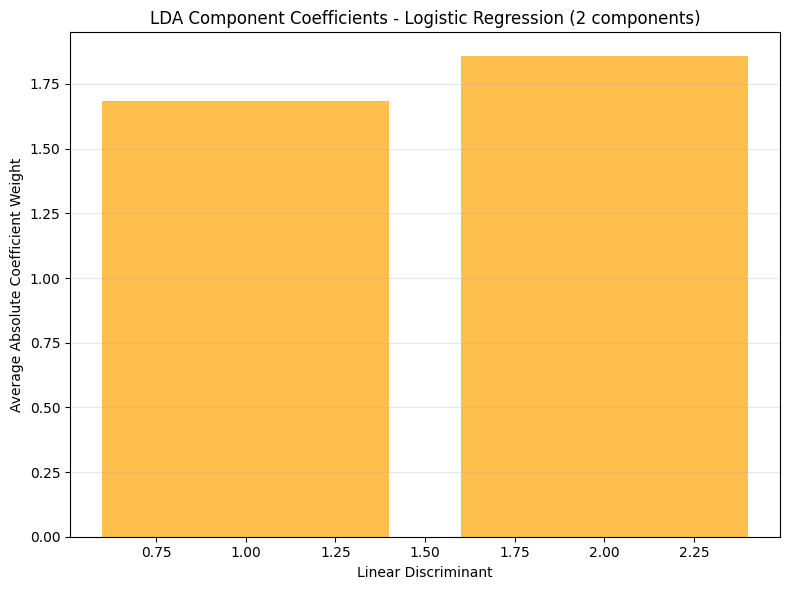


LDA Logistic Regression Details:
Regularization strength (C): 0.01
Penalty type: l2
Convergence: Converged


In [ ]:
# 3. LDA Analysis and Logistic Regression on LDA Features
print("=" * 60)
print("3. LDA ANALYSIS AND LOGISTIC REGRESSION ON LDA FEATURES")
print("=" * 60)

from utils.lda_analysis_functions import quick_lda_analysis

# Quick LDA analysis for KNN
results = quick_lda_analysis(X_train_scaled, X_test_scaled, y_train, y_test, 
                           classifier_name='Logistic Regression', label_encoder=label_encoder)